# Advanced Maze Solver

In [125]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import time
import os
import random

In [126]:
def real_time_visualization(frames, save_dir=None):
    if save_dir and not os.path.exists(save_dir):
      os.makedirs(save_dir)

    for idx, frame in enumerate(frames):
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 8)) # Adjust figure size for better visibility
        ax.imshow(frame, cmap="binary")

        # Add grid lines
        ax.set_xticks(np.arange(-.5, frame.shape[1], 1), minor=True)
        ax.set_yticks(np.arange(-.5, frame.shape[0], 1), minor=True)
        ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5)

        ax.axis("off") # Still turn off axis labels/ticks, but grid remains
        display(fig)

        if save_dir:
            # Save the figure using the helper function
            filename = os.path.join(save_dir, f"maze_frame_{idx:04d}.png")
            save_static_maze_image(frame, filename)

        plt.close(fig)
        time.sleep(0.1) # Reduce sleep time for a slightly faster animation

def save_static_maze_image(maze_grid: np.ndarray, filename: str):
    """
    Lưu một ảnh tĩnh của lưới mê cung.

    Args:
        maze_grid (np.ndarray): Lưới mê cung (mảng numpy).
        filename (str): Đường dẫn và tên tệp để lưu ảnh.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(maze_grid, cmap="binary")

    ax.set_xticks(np.arange(-.5, maze_grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, maze_grid.shape[0], 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5)
    ax.axis("off")
    plt.savefig(filename, bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    print(f"Ảnh mê cung tĩnh đã được lưu vào {filename}")

## 1. Khởi tạo Maze

**1.1. Backtracking Algorithm**

Hàm `dfs_maze_generation` triển khai thuật toán tạo mê cung dựa trên tìm kiếm theo chiều sâu (DFS).:

-   Sử dụng một stack để lưu trữ các ô cần thăm.
-   `visited` lưu trữ các ô đã thăm để tránh lặp lại.
-   Khi thăm một ô mới, nó được đánh dấu là `_1` (đường đi).
-   Thuật toán chọn ngẫu nhiên một trong bốn hướng để di chuyển đến ô láng giềng chưa thăm.
-   Nó phá hủy bức tường giữa ô hiện tại và ô láng giềng được chọn.
-   `frames` lưu trữ trạng thái mê cung ở mỗi bước để hiển thị hoạt hình.

In [127]:
# DFS Algorithm
def dfs_maze_generation(maze, start):
    rows, cols = maze.shape
    stack = [start]
    frames = []
    visited = set()
    visited.add(start)

    while stack:
        current = stack.pop()
        x, y = current
        maze[x, y] = -1  # Mark the current cell as part of the path
        frames.append(maze.copy())

        directions = [(0, 1), (1, 0), (0, -1), (-1, 0)]
        random.shuffle(directions)

        for dx, dy in directions:
            nx, ny = x + dx * 2, y + dy * 2
            if 0 <= nx < rows and 0 <= ny < cols and (nx, ny) not in visited:
                visited.add((nx, ny))
                stack.append((nx, ny))
                maze[x + dx, y + dy] = -1

    return frames

**1.2. Randomized Prim's Algorithm**

Hàm `prim_maze_generation` triển khai thuật toán Prim ngẫu nhiên để tạo mê cung:

-   Bắt đầu với một ô duy nhất và thêm nó vào tập hợp các ô đã thăm (`visited`).
-   Tất cả các bức tường xung quanh ô đó được thêm vào danh sách `walls`.
-   Trong một vòng lặp, một bức tường ngẫu nhiên từ danh sách `walls` được chọn.
-   Nếu ô chưa thăm phía bên kia bức tường đã chọn, bức tường đó sẽ bị phá hủy (được đánh dấu là `_1`), và ô mới được thêm vào `visited`.
-   Các bức tường mới xung quanh ô mới này sau đó được thêm vào danh sách `walls`.
-   Quá trình này tiếp tục cho đến khi không còn bức tường nào trong danh sách có thể nối một ô đã thăm với một ô chưa thăm.

In [128]:
# Prim's Algorithm
def prim_maze_generation(maze, start):
    rows, cols = maze.shape
    frames = []

    maze[start] = -1
    frames.append(maze.copy())
    visited = set([start])
    walls = []

    def add_walls_of_cell(cx, cy):
        for dx, dy in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
            wx, wy = cx + dx, cy + dy
            nx, ny = cx + dx * 2, cy + dy * 2

            if 0 <= nx < rows and 0 <= ny < cols and (nx, ny) not in visited:
                walls.append((wx, wy, nx, ny))

    add_walls_of_cell(start[0], start[1])

    while walls:
        wall_data = random.choice(walls)
        walls.remove(wall_data)
        wx, wy, nx, ny = wall_data

        if (nx, ny) not in visited:
            maze[wx, wy] = -1
            maze[nx, ny] = -1
            frames.append(maze.copy())
            visited.add((nx, ny))
            add_walls_of_cell(nx, ny)

    return frames

**1.3. Hunt and Kill Algorithm**

Hàm `hunt_and_kill_maze_generation` triển khai thuật toán Hunt and Kill để tạo mê cung:

-   **Phase "Walk"**: Bắt đầu từ một ô ngẫu nhiên, nó di chuyển đến một ô láng giềng chưa thăm bằng cách phá hủy bức tường giữa chúng. Quá trình này tiếp tục cho đến khi không có ô láng giềng chưa thăm nào.
-   **Phase "Hunt"**: Khi không thể di chuyển thêm, thuật toán quét qua toàn bộ mê cung để tìm ô chưa thăm đầu tiên có ít nhất một ô láng giềng đã được thăm. Nó phá hủy bức tường giữa ô chưa thăm này và một trong các ô láng giềng đã thăm, sau đó bắt đầu lại Phase "Walk" từ ô này.
-   Quá trình này lặp lại cho đến khi tất cả các ô đều được thăm.

In [129]:
# Hunt and Kill Algorithm
def hunt_and_kill_maze_generation(maze, start):
    rows, cols = maze.shape
    frames = []
    visited = set()
    current = start

    while True:
        maze[current] = -1
        visited.add(current)
        frames.append(maze.copy())

        directions = [(0, 1), (1, 0), (0, -1), (-1, 0)]
        random.shuffle(directions)

        found_unvisited_neighbor = False
        for dx, dy in directions:
            nx, ny = current[0] + dx * 2, current[1] + dy * 2
            if 0 <= nx < rows and 0 <= ny < cols and (nx, ny) not in visited:
                visited.add((nx, ny))
                maze[current[0] + dx, current[1] + dy] = -1
                current = (nx, ny)
                found_unvisited_neighbor = True
                break

        if not found_unvisited_neighbor:
            found_next_start = False
            for i in range(1, rows, 2):
                for j in range(1, cols, 2):
                    if (i, j) not in visited:
                        for dx, dy in directions:
                            adj_x, adj_y = i + dx * 2, j + dy * 2
                            if (adj_x, adj_y) in visited:
                                maze[i + dx, j + dy] = -1
                                current = (i, j)
                                found_next_start = True
                                break
                        if found_next_start:
                            break
                if found_next_start:
                    break

            if not found_next_start:
                break

    return frames

**1.4. Sidewinder Algorithm**

Hàm `sidewinder_maze_generation` triển khai thuật toán Sidewinder để tạo mê cung:

-   Thuật toán này xử lý mê cung theo từng hàng.
-   Nó đi qua mỗi ô trong hàng, ngẫu nhiên quyết định có phá hủy bức tường bên phải của ô đó hay không. Nếu phá, nó tiếp tục xây dựng một "run" (chuỗi các ô liên tiếp).
-   Nếu không phá tường bên phải (hoặc ở cuối hàng), nó sẽ chọn ngẫu nhiên một ô trong "run" hiện tại và phá hủy bức tường phía trên của ô đó để nối nó với hàng phía trên. Sau đó, "run" được đặt lại.
-   Điều này tạo ra một mê cung với xu hướng có các hành lang dài theo chiều ngang.

In [130]:
# Sidewinder Algorithm
def sidewinder_maze_generation(maze):
    rows, cols = maze.shape
    frames = []

    for i in range(1, rows, 2):
        current_run = []

        for j in range(1, cols, 2):
            current = (i, j)
            maze[current] = -1
            current_run.append(current)
            frames.append(maze.copy())

            can_go_right = (j + 2) < cols
            can_go_up = (i - 2) > 0

            if can_go_right and (not can_go_up or random.choice([True, False])):
                maze[i, j + 1] = -1
                frames.append(maze.copy())
            else:
                if can_go_up:
                    member_i, member_j = random.choice(current_run)
                    maze[member_i - 1, member_j] = -1
                    frames.append(maze.copy())

                current_run = []

    return frames

**1.5. You're My Special - Origin Shift**

Hàm `origin_shift_maze_generation` triển khai thuật toán Origin Shift, một phương pháp độc đáo để tạo mê cung:

-   Ban đầu, nó tạo ra một mê cung "cây" (spanning tree) đơn giản bằng cách kết nối mỗi ô với ô bên trái hoặc ô phía trên của nó.
-   Sau đó, trong một số bước (`steps`) đã định, nó ngẫu nhiên chọn một ô và một ô láng giềng đã được kết nối (thông qua tường bị phá). Nếu việc thay đổi mối quan hệ cha-con (parent) của ô hiện tại với láng giềng này không tạo ra một chu trình (cycle) hoặc không đảo ngược mối quan hệ hiện có, nó sẽ phá vỡ bức tường cũ và tạo ra một bức tường mới để kết nối ô hiện tại với láng giềng mới.
-   Quá trình này "dịch chuyển" các gốc cây con, tạo ra mê cung phức tạp hơn với nhiều nhánh và đường đi vòng.

In [131]:
# Origin Shift Algorithm (CaptainLuma)
def origin_shift_maze_generation(maze, steps=100):
    rows, cols = maze.shape
    frames = []

    cell_rows = (rows - 1) // 2
    cell_cols = (cols - 1) // 2

    maze.fill(1)

    parent = {}

    for r in range(1, rows, 2):
        for c in range(1, cols, 2):
            maze[r, c] = -1

            if c > 1:
                parent[(r, c)] = (r, c - 2)
                maze[r, c - 1] = -1
            elif r > 1:
                parent[(r, c)] = (r - 2, c)
                maze[r - 1, c] = -1

    frames.append(maze.copy())

    for _ in range(steps):
        r = random.randrange(1, rows, 2)
        c = random.randrange(1, cols, 2)
        current = (r, c)

        neighbors = []
        for dr, dc in [(0, 2), (2, 0), (0, -2), (-2, 0)]:
            nr, nc = r + dr, c + dc
            if 1 <= nr < rows and 1 <= nc < cols:
                neighbors.append((nr, nc, dr // 2, dc // 2))

        if not neighbors:
            continue

        nr, nc, dr, dc = random.choice(neighbors)
        target = (nr, nc)

        if parent.get(current) != target and parent.get(target) != current:
            if current in parent:
                old_parent = parent[current]
                wall_r = (current[0] + old_parent[0]) // 2
                wall_c = (current[1] + old_parent[1]) // 2
                maze[wall_r, wall_c] = 1

            parent[current] = target

            new_wall_r = current[0] + dr
            new_wall_c = current[1] + dc
            maze[new_wall_r, new_wall_c] = -1

            frames.append(maze.copy())

    return frames

**1.6. Hàm Tạo Mê Cung Kết Hợp**

Hàm `generate_maze` này cung cấp một giao diện thống nhất để tạo mê cung sử dụng các thuật toán khác nhau. Nó nhận kích thước logic `n`, một `start_point` tùy chọn (có liên quan đến một số thuật toán), và `method` làm tham số. Nó sẽ trả về một danh sách các khung hình có thể được sử dụng với `real_time_visualization`.

In [132]:
def generate_maze(n, start_point=(1, 1), method='dfs'):
    """
    Tạo mê cung bằng cách sử dụng thuật toán được chỉ định.

    Args:
        n (int): Kích thước logic của mê cung (ví dụ, n=11 cho một lưới ô 11x11).
        start_point (tuple, optional): Điểm bắt đầu cho các thuật toán yêu cầu (hàng, cột). Mặc định là (1, 1).
        method (str, optional): Thuật toán tạo mê cung để sử dụng.
                                 Chọn từ 'dfs', 'prim', 'hunt_and_kill', 'sidewinder', 'origin_shift'.
                                 Mặc định là 'dfs'.

    Returns:
        list: Một danh sách các khung mê cung (mảng numpy) đại diện cho quá trình tạo.

    Raises:
        ValueError: Nếu một phương pháp tạo mê cung không hợp lệ được chỉ định.
    """
    maze_size = n * 2 + 1

    # Prepare a basic grid with cells (0) and walls (1) for algorithms that use it
    initial_maze_grid = np.ones((maze_size, maze_size), dtype=int)
    initial_maze_grid[1::2, 1::2] = 0

    frames = []

    if method == 'dfs':
        frames = dfs_maze_generation(initial_maze_grid.copy(), start_point)
    elif method == 'prim':
        frames = prim_maze_generation(initial_maze_grid.copy(), start_point)
    elif method == 'hunt_and_kill':
        frames = hunt_and_kill_maze_generation(initial_maze_grid.copy(), start_point)
    elif method == 'sidewinder':
        # Sidewinder works well with an initial grid setup
        frames = sidewinder_maze_generation(initial_maze_grid.copy())
    elif method == 'origin_shift':
        # Origin Shift initializes its own maze, but needs the correct dimensions.
        # Passing a fresh maze for it to fill.
        origin_shift_specific_maze = np.zeros((maze_size, maze_size), dtype=int)
        frames = origin_shift_maze_generation(origin_shift_specific_maze, steps=100)
    else:
        raise ValueError("Invalid maze generation method specified. Choose from 'dfs', 'prim', 'hunt_and_kill', 'sidewinder', 'origin_shift'.")

    return frames

#### Ví dụ sử dụng `generate_maze`

Hãy cùng tạo và hiển thị trực quan các mê cung sử dụng các thuật toán khác nhau thông qua hàm `generate_maze` mới.

#### Parameters:

-   `n`: Định nghĩa kích thước 'lôgic' của mê cung (ví dụ, `n=11` có nghĩa là 11x11 ô trống).
-   `maze_size`: Tính toán kích thước thực tế của ma trận mê cung, bao gồm cả tường (mỗi ô trống sẽ có tường xung quanh, nên `n * 2 + 1`).
-   `maze`: Tạo một ma trận NumPy với tất cả các giá trị là `1` (biểu thị tường). Sau đó, đặt các ô trống ban đầu là `0` (các ô có thể đi qua). `maze[1::2, 1::2] = 0` tạo ra một lưới các ô trống được ngăn cách bởi tường.
-   `start_point`: Xác định điểm bắt đầu cho việc tạo mê cung, thường là ô trống đầu tiên (1,1).

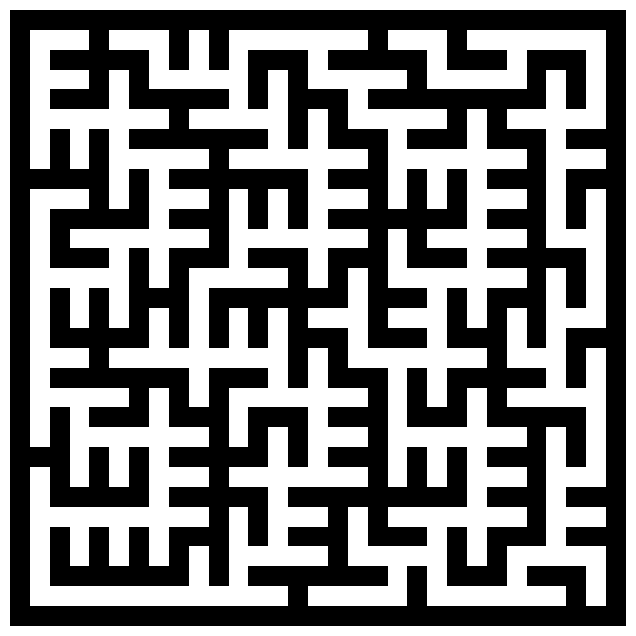

Ảnh mê cung tĩnh đã được lưu vào dfs_maze_frames/maze_frame_0224.png
Ảnh mê cung tĩnh đã được lưu vào maze_dfs.png


In [133]:
# Ví dụ 1: Mê cung DFS
print("Đang tạo mê cung DFS...")
dfs_frames = generate_maze(n=15, start_point=(1, 1), method='dfs')
real_time_visualization(dfs_frames, save_dir='dfs_maze_frames')
# Lưu ảnh mê cung DFS cuối cùng
save_static_maze_image(dfs_frames[-1], 'maze_dfs.png')

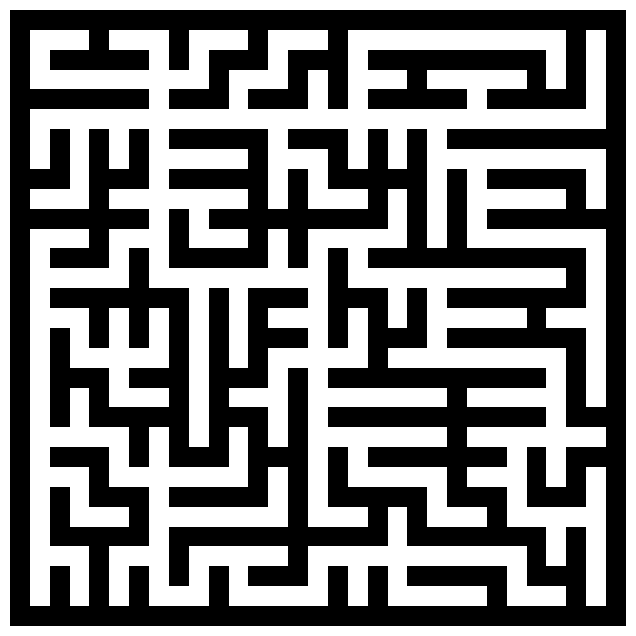

Ảnh mê cung tĩnh đã được lưu vào prim_maze_frames/maze_frame_0224.png
Ảnh mê cung tĩnh đã được lưu vào maze_prim.png


In [134]:
# Ví dụ 2: Mê cung Prim
print("Đang tạo mê cung Prim...")
prim_frames = generate_maze(n=15, start_point=(1, 1), method='prim')
real_time_visualization(prim_frames, save_dir='prim_maze_frames')
# Lưu ảnh mê cung Prim cuối cùng
save_static_maze_image(prim_frames[-1], 'maze_prim.png')

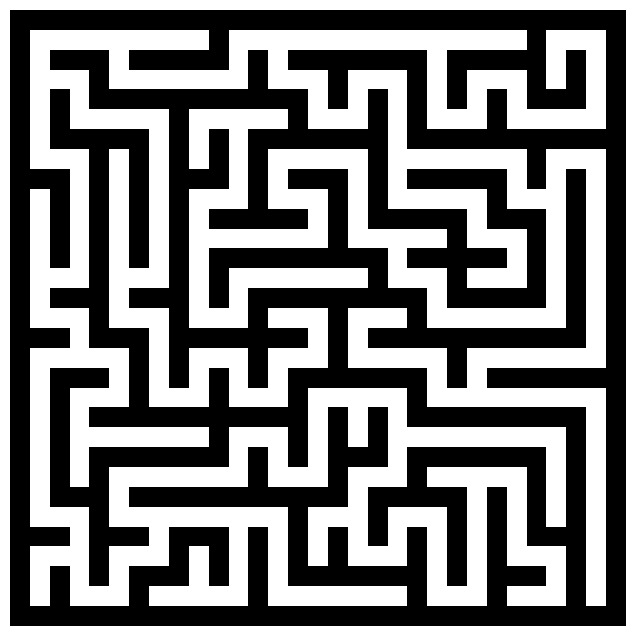

Ảnh mê cung tĩnh đã được lưu vào hunt_kill_maze_frames/maze_frame_0224.png
Ảnh mê cung tĩnh đã được lưu vào maze_hunt_kill.png


In [135]:
# Ví dụ 3: Mê cung Hunt and Kill
print("Đang tạo mê cung Hunt and Kill...")
hunt_kill_frames = generate_maze(n=15, start_point=(1, 1), method='hunt_and_kill')
real_time_visualization(hunt_kill_frames, save_dir='hunt_kill_maze_frames')
save_static_maze_image(hunt_kill_frames[-1], 'maze_hunt_kill.png')

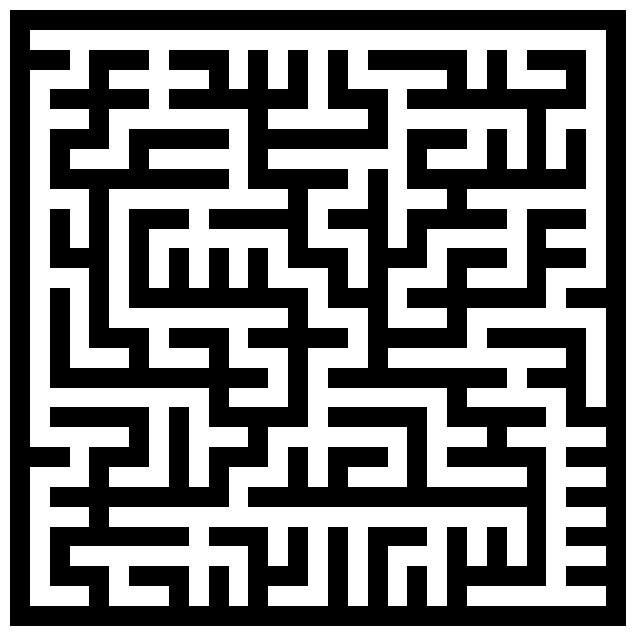

Ảnh mê cung tĩnh đã được lưu vào sidewinder_maze_frames/maze_frame_0448.png
Ảnh mê cung tĩnh đã được lưu vào maze_sidewinder.png


In [136]:
# Ví dụ 4: Mê cung Sidewinder
print("Đang tạo mê cung Sidewinder...")
sidewinder_frames = generate_maze(n=15, method='sidewinder')
real_time_visualization(sidewinder_frames, save_dir='sidewinder_maze_frames')
# Lưu ảnh mê cung Sidewinder cuối cùng
save_static_maze_image(sidewinder_frames[-1], 'maze_sidewinder.png')

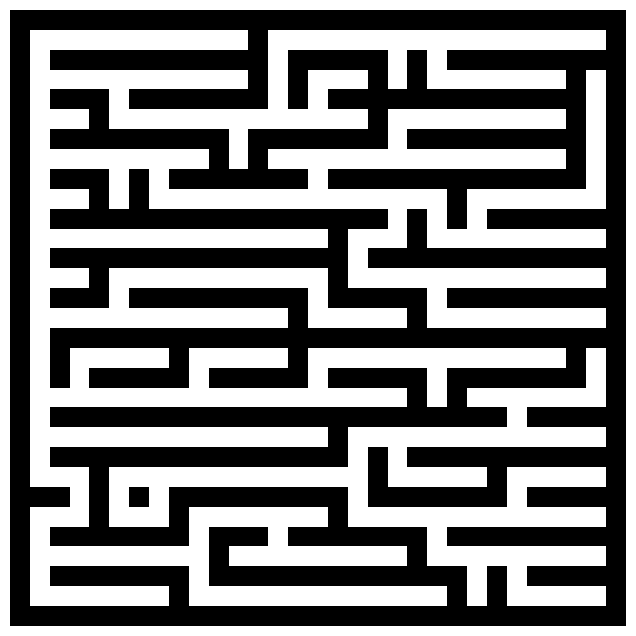

Ảnh mê cung tĩnh đã được lưu vào origin_shift_maze_frames/maze_frame_0052.png
Ảnh mê cung tĩnh đã được lưu vào maze_origin_shift.png


In [137]:
# Ví dụ 5: Mê cung Origin Shift
print("Đang tạo mê cung Origin Shift...")
origin_shift_frames = generate_maze(n=15, method='origin_shift')
real_time_visualization(origin_shift_frames, save_dir='origin_shift_maze_frames')
# Lưu ảnh mê cung Origin Shift cuối cùng
save_static_maze_image(origin_shift_frames[-1], 'maze_origin_shift.png')

### Giải mê cung bằng thuật toán DFS

Để giải mê cung, chúng ta cần định nghĩa một số cấu trúc dữ liệu và một hàm giải quyết.

Đầu tiên, chúng ta sẽ định nghĩa một lớp `Position` cho tọa độ, `MazeModel` để biểu diễn mê cung có thể giải được, `SearchResult` để lưu trữ kết quả tìm kiếm và `MazeSolver` để tái tạo đường đi.

In [138]:
# Helper class and functions

from typing import NamedTuple, Iterator

class Position(NamedTuple):
    row: int
    col: int

class SearchResult(NamedTuple):
    algorithm: str
    found: bool
    path: list[Position]
    visited_order: list[Position]
    edges: list[tuple[Position, Position]]
    nodes_expanded: int
    max_frontier: int
    elapsed_ms: float
    completeness: str
    optimality: str
    time_complexity: str
    space_complexity: str

class MazeModel:
    def __init__(self, maze_grid: np.ndarray, start: Position, goal: Position):
        self.maze_grid = maze_grid
        self.rows, self.cols = maze_grid.shape
        self.start = start
        self.goal = goal

        # Validate start and goal positions
        if not (0 <= start.row < self.rows and 0 <= start.col < self.cols and maze_grid[start] == -1):
            raise ValueError(f"Start position {start} is invalid or blocked.")
        if not (0 <= goal.row < self.rows and 0 <= goal.col < self.cols and maze_grid[goal] == -1):
            raise ValueError(f"Goal position {goal} is invalid or blocked.")

    def neighbors(self, pos: Position) -> Iterator[tuple[str, Position]]:
        possible_moves = [
            ('U', Position(pos.row - 2, pos.col)),
            ('D', Position(pos.row + 2, pos.col)),
            ('L', Position(pos.row, pos.col - 2)),
            ('R', Position(pos.row, pos.col + 2)),
        ]
        for direction, next_pos in possible_moves:
            # Check if next_pos is within bounds and the path between current and next_pos is clear (-1)
            if 0 <= next_pos.row < self.rows and \
               0 <= next_pos.col < self.cols and \
               self.maze_grid[next_pos.row, next_pos.col] == -1:
                # Check the wall between current and next_pos
                wall_row = (pos.row + next_pos.row) // 2
                wall_col = (pos.col + next_pos.col) // 2
                if self.maze_grid[wall_row, wall_col] == -1:
                    yield direction, next_pos

class MazeSolver:
    @staticmethod
    def reconstruct_path(parent: dict[Position, Position | None],
                         goal: Position) -> list[Position]:
        path = []
        current = goal
        while current is not None:
            path.append(current)
            current = parent.get(current)
        return path[::-1]

    @staticmethod
    def manhattan(a: Position, b: Position) -> float:
        return abs(a.row - b.row) + abs(a.col - b.col)

    @staticmethod
    def euclidean(a: Position, b: Position) -> float:
        return ((a.row - b.row)**2 + (a.col - b.col)**2)**0.5

# Tạo một hàm visualize_solved_maze để hiển thị mê cung đã tạo, đường đi đã tìm thấy và các ô đã thăm.
def visualize_solved_maze(maze_grid: np.ndarray, result: SearchResult,
                          start: Position, goal: Position, save_path: str = None):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(maze_grid, cmap='binary') # Use binary for walls (1) and paths (-1/0)

    # Mark visited cells (light gray)
    for pos in result.visited_order:
        ax.plot(pos.col, pos.row, 'o', color='lightgray', markersize=4)

    # Mark the path (blue)
    for i in range(len(result.path) - 1):
        p1 = result.path[i]
        p2 = result.path[i+1]
        # Draw line between cell centers
        ax.plot([p1.col, p2.col], [p1.row, p2.row], color='blue', linewidth=2)
        # Fill the wall between them if exists in maze_grid
        mid_row = (p1.row + p2.row) // 2
        mid_col = (p1.col + p2.col) // 2
        ax.plot(mid_col, mid_row, 'o', color='blue', markersize=2)

    # Mark start and goal
    ax.plot(start.col, start.row, 'o', color='green', markersize=8, label='Start')
    ax.plot(goal.col, goal.row, 'o', color='red', markersize=8, label='Goal')

    ax.set_xticks(np.arange(-.5, maze_grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, maze_grid.shape[0], 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=0.5)
    ax.axis('off')
    ax.set_title(f"Maze Solved by {result.algorithm}")

    if save_path:
        if not os.path.exists(os.path.dirname(save_path)) and os.path.dirname(save_path) != '':
            os.makedirs(os.path.dirname(save_path))
        plt.savefig(save_path)
        print(f"Maze saved to {save_path}")

    plt.show()

In [139]:
import time # Ensure time is imported for time.perf_counter
from collections import deque
from heapq import heappush, heappop

def bfs_solve(model: MazeModel) -> SearchResult:
    """Breadth-first search: FIFO frontier, shortest path when step cost is uniform."""
    start_t = time.perf_counter()
    q = deque([model.start])
    parent: dict[Position, Position | None] = {model.start: None}
    visited = {model.start}
    visited_order: list[Position] = []
    edges: list[tuple[Position, Position]] = []
    max_frontier = 1

    while q:
        max_frontier = max(max_frontier, len(q))
        cur = q.popleft()
        visited_order.append(cur)
        if cur == model.goal:
            break
        for _, nxt in model.neighbors(cur):
            if nxt in visited:
                continue
            visited.add(nxt)
            parent[nxt] = cur
            edges.append((cur, nxt))
            q.append(nxt)

    path = MazeSolver.reconstruct_path(parent, model.goal)
    elapsed = (time.perf_counter() - start_t) * 1000
    return SearchResult(
        algorithm="BFS",
        found=bool(path),
        path=path,
        visited_order=visited_order,
        edges=edges,
        nodes_expanded=len(visited_order),
        max_frontier=max_frontier,
        elapsed_ms=elapsed,
        completeness="Complete",
        optimality="Optimal (uniform step costs)",
        time_complexity="O(V + E)",
        space_complexity="O(V)",
    )


def dfs_solve(model: MazeModel) -> SearchResult:
    """Depth-first search: LIFO stack; explores one branch deeply before backtracking."""
    start_t = time.perf_counter()
    stack = [model.start]
    parent: dict[Position, Position | None] = {model.start: None}
    visited = {model.start}
    visited_order: list[Position] = []
    edges: list[tuple[Position, Position]] = []
    max_frontier = 1

    while stack:
        max_frontier = max(max_frontier, len(stack))
        cur = stack.pop()
        visited_order.append(cur)
        if cur == model.goal:
            break
        # Reversed neighbor order makes expansion order deterministic for the demo.
        for _, nxt in reversed(list(model.neighbors(cur))): # Convert iterator to list for reversed()
            if nxt in visited:
                continue
            visited.add(nxt)
            parent[nxt] = cur
            edges.append((cur, nxt))
            stack.append(nxt)

    path = MazeSolver.reconstruct_path(parent, model.goal)
    elapsed = (time.perf_counter() - start_t) * 1000
    return SearchResult(
        algorithm="DFS",
        found=bool(path),
        path=path,
        visited_order=visited_order,
        edges=edges,
        nodes_expanded=len(visited_order),
        max_frontier=max_frontier,
        elapsed_ms=elapsed,
        completeness="Complete (finite graph + visited set)",
        optimality="Not optimal",
        time_complexity="O(V + E)",
        space_complexity="O(V)",
    )


def greedy_best_first_solve(model: MazeModel, heuristic_name: str) -> SearchResult:
    """Greedy best-first: expand the cell with smallest h(n) to the goal."""
    heuristic = MazeSolver.manhattan if heuristic_name == "Manhattan" else MazeSolver.euclidean
    start_t = time.perf_counter()
    pq: list[tuple[float, Position]] = []
    heappush(pq, (heuristic(model.start, model.goal), model.start))
    parent: dict[Position, Position | None] = {model.start: None}
    visited = {model.start}
    visited_order: list[Position] = []
    edges: list[tuple[Position, Position]] = []
    max_frontier = 1

    while pq:
        max_frontier = max(max_frontier, len(pq))
        _, cur = heappop(pq)
        visited_order.append(cur)
        if cur == model.goal:
            break
        for _, nxt in model.neighbors(cur):
            if nxt in visited:
                continue
            visited.add(nxt)
            parent[nxt] = cur
            edges.append((cur, nxt))
            heappush(pq, (heuristic(nxt, model.goal), nxt))

    path = MazeSolver.reconstruct_path(parent, model.goal)
    elapsed = (time.perf_counter() - start_t) * 1000
    return SearchResult(
        algorithm=f"Greedy Best-First ({heuristic_name})",
        found=bool(path),
        path=path,
        visited_order=visited_order,
        edges=edges,
        nodes_expanded=len(visited_order),
        max_frontier=max_frontier,
        elapsed_ms=elapsed,
        completeness="Complete (finite graph + visited set)",
        optimality="Not optimal",
        time_complexity="O(E log V)",
        space_complexity="O(V)",
    )

def a_star_solve(model: MazeModel, heuristic_name: str) -> SearchResult:
    """A*: expand lowest f(n) = g(n) + h(n); optimal with admissible heuristic."""
    heuristic = MazeSolver.manhattan if heuristic_name == "Manhattan" else MazeSolver.euclidean
    start_t = time.perf_counter()
    pq: list[tuple[float, Position]] = []
    g_cost: dict[Position, float] = {model.start: 0.0}
    parent: dict[Position, Position | None] = {model.start: None}
    heappush(pq, (heuristic(model.start, model.goal), model.start))
    closed: set[Position] = set()
    visited_order: list[Position] = []
    edges: list[tuple[Position, Position]] = []
    max_frontier = 1

    while pq:
        max_frontier = max(max_frontier, len(pq))
        _, cur = heappop(pq)
        if cur in closed:
            continue
        closed.add(cur)
        visited_order.append(cur)
        if cur == model.goal:
            break

        for _, nxt in model.neighbors(cur):
            tentative = g_cost[cur] + 1.0
            if tentative < g_cost.get(nxt, float("inf")):
                g_cost[nxt] = tentative
                parent[nxt] = cur
                edges.append((cur, nxt))
                f = tentative + heuristic(nxt, model.goal)
                heappush(pq, (f, nxt))

    path = MazeSolver.reconstruct_path(parent, model.goal)
    elapsed = (time.perf_counter() - start_t) * 1000
    return SearchResult(
        algorithm=f"A* ({heuristic_name})",
        found=bool(path),
        path=path,
        visited_order=visited_order,
        edges=edges,
        nodes_expanded=len(visited_order),
        max_frontier=max_frontier,
        elapsed_ms=elapsed,
        completeness="Complete (finite graph + positive costs)",
        optimality="Optimal (admissible/consistent heuristic)",
        time_complexity="O(E log V)",
        space_complexity="O(V)",
    )


Tạo mê cung

In [140]:
# 1. Tạo một mê cung (ví dụ: sử dụng DFS)
print("Đang tạo mê cung cho việc giải...")
n_solve = 15
solve_dfs_frames = generate_maze(n=n_solve, start_point=(1, 1), method='dfs')
final_maze_grid = solve_dfs_frames[-1] # Lấy khung mê cung cuối cùng

# Xác định điểm bắt đầu và kết thúc cho việc giải
# Các vị trí này phải là các ô hợp lệ (-1) trong mê cung
start_solve = Position(1, 1)
goal_solve = Position(n_solve * 2 - 1, n_solve * 2 - 1)

# 2. Tạo MazeModel
maze_model = MazeModel(final_maze_grid, start_solve, goal_solve)

# 3. Giải bằng các thuật toán

Đang tạo mê cung cho việc giải...


### Giải mê cung bằng thuật toán BFS

Đang giải mê cung bằng BFS...
Đường đi đã tìm thấy với 55 bước.
Số nút mở rộng: 124
Thời gian đã trôi qua: 0.84 ms
Maze saved to ./solved_maze_bfs.png


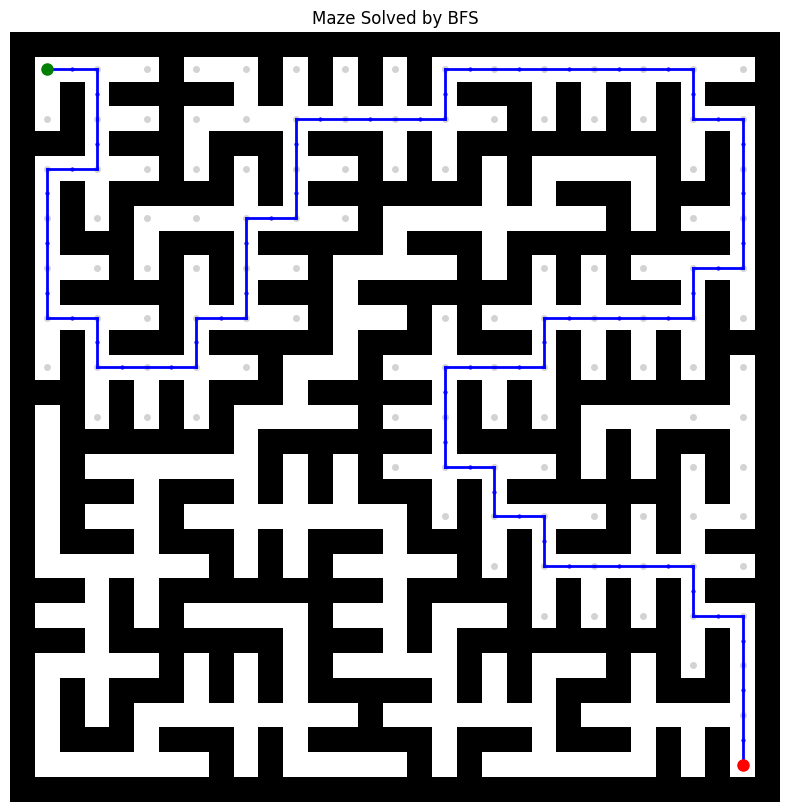

In [141]:
# Giải mê cung bằng BFS
print("Đang giải mê cung bằng BFS...")
bfs_solution_result = bfs_solve(maze_model)

# Hiển thị mê cung đã giải và lưu hình ảnh
if bfs_solution_result.found:
    print(f"Đường đi đã tìm thấy với {len(bfs_solution_result.path)} bước.")
    print(f"Số nút mở rộng: {bfs_solution_result.nodes_expanded}")
    print(f"Thời gian đã trôi qua: {bfs_solution_result.elapsed_ms:.2f} ms")
    visualize_solved_maze(final_maze_grid, bfs_solution_result, start_solve, goal_solve, save_path='./solved_maze_bfs.png')
else:
    print("Không tìm thấy đường đi.")

### Giải mê cung bằng thuật toán DFS

Đang giải mê cung bằng DFS...
Đường đi đã tìm thấy với 55 bước.
Số nút mở rộng: 106
Thời gian đã trôi qua: 1.03 ms
Maze saved to ./solved_maze_dfs.png


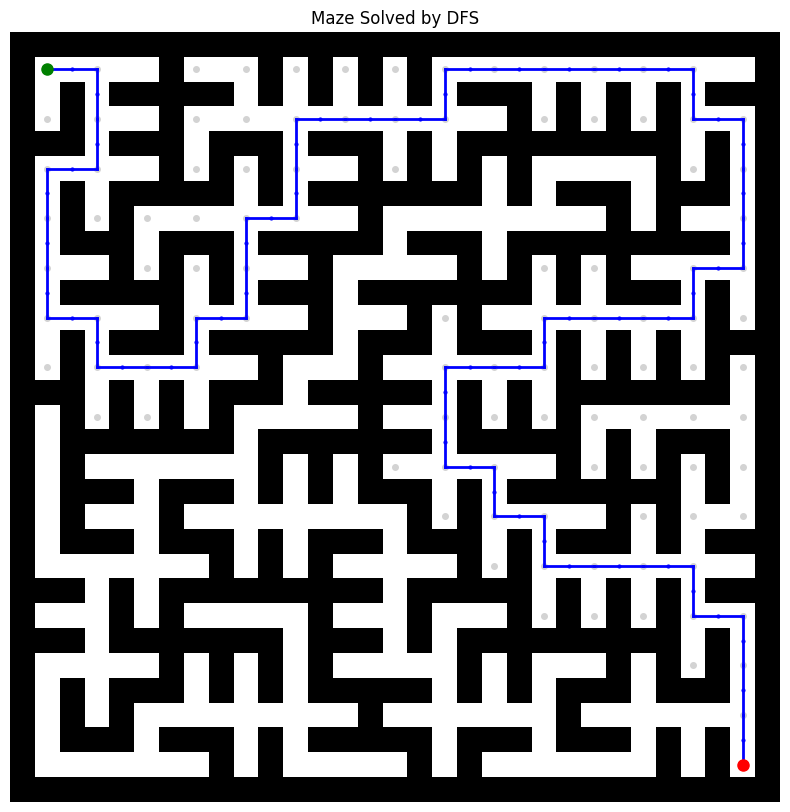

In [142]:
# Giải mê cung bằng DFS
print("Đang giải mê cung bằng DFS...")
dfs_solution_result = dfs_solve(maze_model)

# Hiển thị mê cung đã giải và lưu hình ảnh
if dfs_solution_result.found:
    print(f"Đường đi đã tìm thấy với {len(dfs_solution_result.path)} bước.")
    print(f"Số nút mở rộng: {dfs_solution_result.nodes_expanded}")
    print(f"Thời gian đã trôi qua: {dfs_solution_result.elapsed_ms:.2f} ms")
    visualize_solved_maze(final_maze_grid, dfs_solution_result, start_solve, goal_solve, save_path='./solved_maze_dfs.png')
else:
    print("Không tìm thấy đường đi.")

### Giải mê cung bằng thuật toán Greedy Best-First (Manhattan Heuristic)

Đang giải mê cung bằng Greedy Best-First (Manhattan)...
Đường đi đã tìm thấy với 55 bước.
Số nút mở rộng: 89
Thời gian đã trôi qua: 1.27 ms
Maze saved to ./solved_maze_greedy_manhattan.png


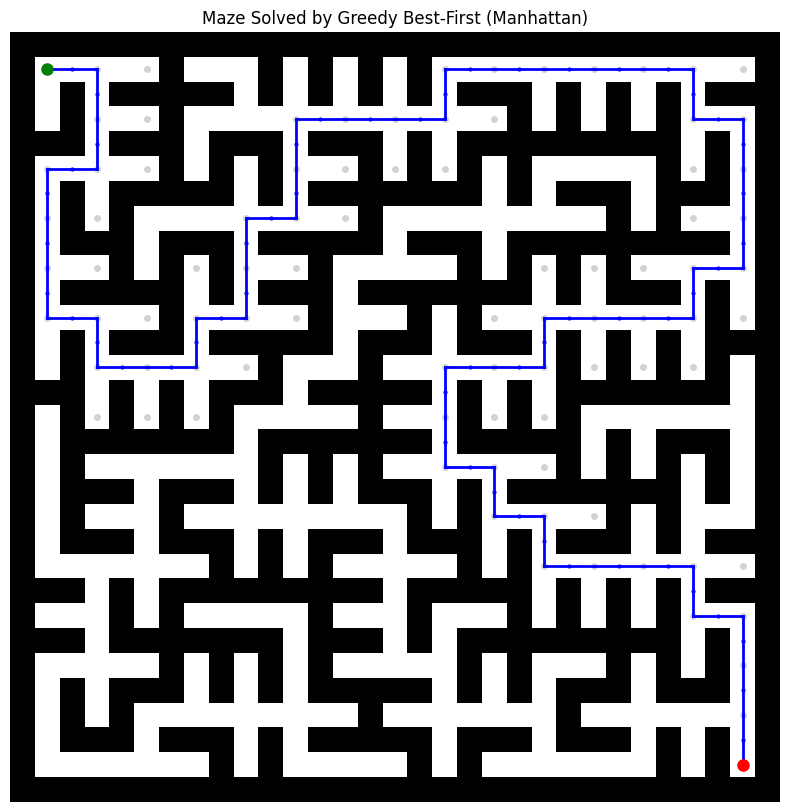

In [143]:
# Giải mê cung bằng Greedy Best-First
print("Đang giải mê cung bằng Greedy Best-First (Manhattan)...")
greedy_solution_result = greedy_best_first_solve(maze_model, heuristic_name="Manhattan")

# Hiển thị mê cung đã giải và lưu hình ảnh
if greedy_solution_result.found:
    print(f"Đường đi đã tìm thấy với {len(greedy_solution_result.path)} bước.")
    print(f"Số nút mở rộng: {greedy_solution_result.nodes_expanded}")
    print(f"Thời gian đã trôi qua: {greedy_solution_result.elapsed_ms:.2f} ms")
    visualize_solved_maze(final_maze_grid, greedy_solution_result, start_solve, goal_solve, save_path='./solved_maze_greedy_manhattan.png')
else:
    print("Không tìm thấy đường đi.")

### Giải mê cung bằng thuật toán A* (Manhattan Heuristic)

Đang giải mê cung bằng A* (Manhattan)...
Đường đi đã tìm thấy với 55 bước.
Số nút mở rộng: 105
Thời gian đã trôi qua: 1.60 ms
Maze saved to ./solved_maze_astar_manhattan.png


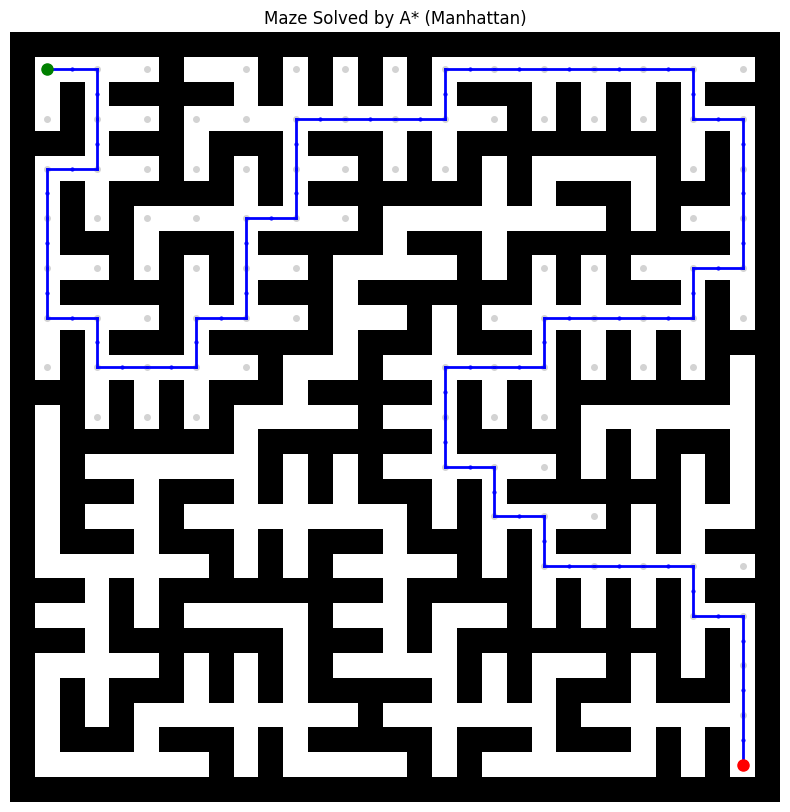

In [144]:
# Giải mê cung bằng A*
print("Đang giải mê cung bằng A* (Manhattan)...")
a_star_solution_result = a_star_solve(maze_model, heuristic_name="Manhattan")

# Hiển thị mê cung đã giải và lưu hình ảnh
if a_star_solution_result.found:
    print(f"Đường đi đã tìm thấy với {len(a_star_solution_result.path)} bước.")
    print(f"Số nút mở rộng: {a_star_solution_result.nodes_expanded}")
    print(f"Thời gian đã trôi qua: {a_star_solution_result.elapsed_ms:.2f} ms")
    visualize_solved_maze(final_maze_grid, a_star_solution_result, start_solve, goal_solve, save_path='./solved_maze_astar_manhattan.png')
else:
    print("Không tìm thấy đường đi.")